In [1]:
import numpy as np
rng= np.random.default_rng(seed = 42)
m = 300
X = 2*rng.random((m,1))
y = 4 + 3*X + rng.standard_normal((m,1))

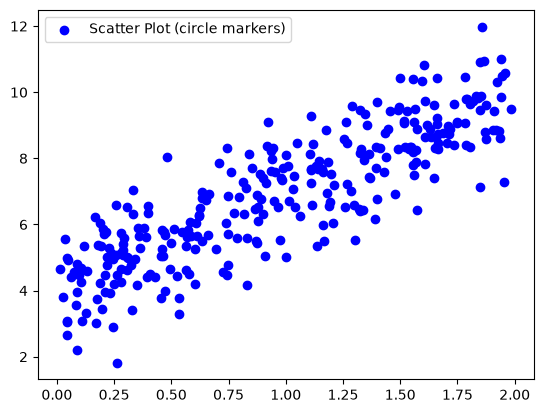

In [2]:
import matplotlib.pyplot as plt 
plt.scatter(X, y, marker='o', color='blue', label='Scatter Plot (circle markers)')
plt.legend()
plt.show()

In [3]:
from sklearn.preprocessing import add_dummy_feature
X_b = add_dummy_feature(X)  # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
theta_best

array([[4.04452753],
       [2.938403  ]])

In [4]:
X_new = np.array([[0],[2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b@theta_best
y_predict

array([[4.04452753],
       [9.92133354]])

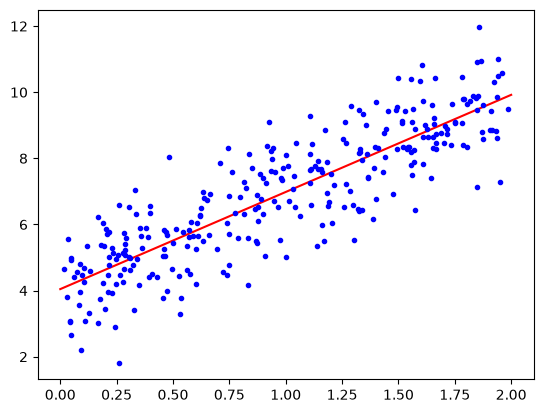

In [5]:
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.")

plt.show()

In [6]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.04452753]), array([[2.938403]]))

In [7]:
eta = 0.1
n_epochs =1000
m = len(X_b)

theta = rng.standard_normal((2, 1))
for epoch in range(n_epochs):
    gradients = 2 / m * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients

In [8]:
theta

array([[4.04452753],
       [2.938403  ]])

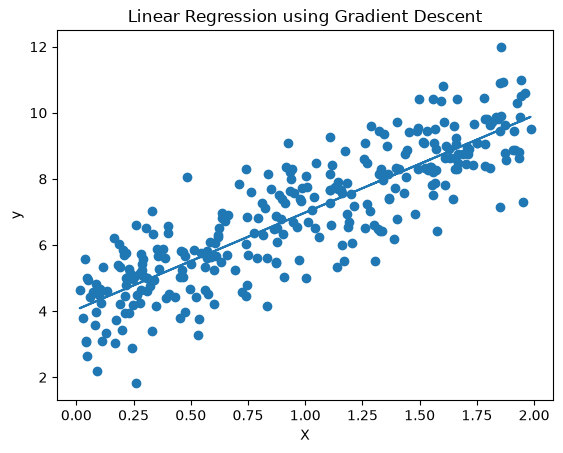

In [9]:
plt.scatter(X, y)

# Predictions using final theta
y_pred = X_b @ theta

plt.plot(X, y_pred)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression using Gradient Descent")
plt.show()

In [10]:
n_epochs = 50
t0,t1 = 5,50
def learning_rate(t):
    return t0/(t+t1)
theta = rng.standard_normal((2, 1)) 
for epoch in range(n_epochs):
    for iterations in range(m):
        rand_idx = rng.integers(m)
        xi = X_b[rand_idx:rand_idx + 1]
        yi = y[rand_idx : rand_idx+1]
        gradients = 2*xi.T@( xi @ theta-yi)
        eta = learning_rate(epoch*m + iterations)
        theta = theta - eta* gradients

theta

array([[4.0175941 ],
       [2.92727743]])

In [15]:
X = 6*rng.random((m,1)) -3
y = 0.5 * X ** 2 + 3 * X + 5 + rng.standard_normal((m,1)) 
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
print(X[0])
X_poly[0]

[-1.54116255]


array([-1.54116255,  2.375182  ])

In [16]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([5.03677834]), array([[2.95831621, 0.48280258]]))

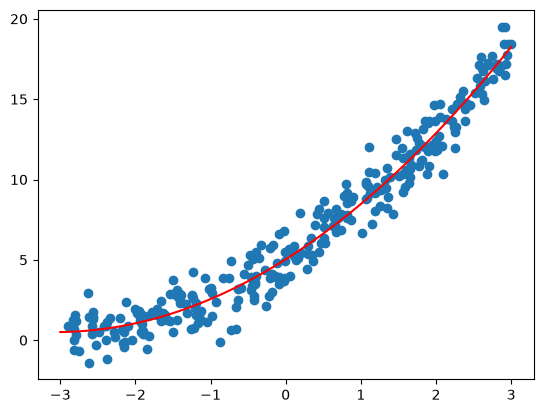

In [22]:
plt.scatter(X,y)
X_new = np.linspace(-3, 3, 100).reshape(-1, 1)
X_new_poly = poly_features.transform(X_new)

y_new = lin_reg.predict(X_new_poly)
plt.plot(X_new,y_new,'r-')
plt.show()

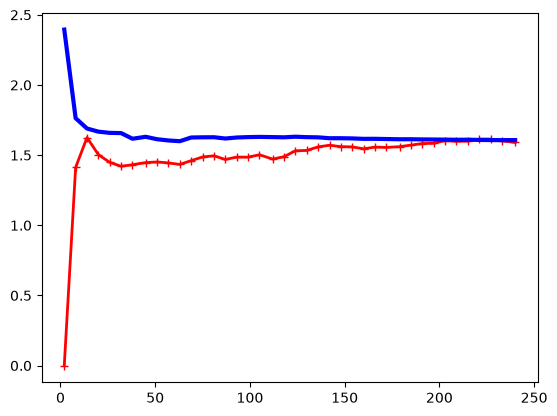

In [23]:
from sklearn.model_selection import learning_curve
train_sizes, train_scores, valid_scores = learning_curve(LinearRegression(), X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,scoring="neg_root_mean_squared_error")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.show()

In [27]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha= 0.1,solver = "cholesky")
ridge_reg.fit(X,y)
ridge_reg.predict([[1.5]])

array([10.93186125])

In [31]:
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(penalty="l2", alpha=0.1 / m, tol=None,
max_iter=1000, eta0=0.01, random_state=42)
sgd_reg.fit(X,y.ravel())
sgd_reg.predict([[1.5]])

array([10.93213675])